In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned_data.csv")

In [ ]:
import sys
print(sys.executable)

c:\Users\hadis\AppData\Local\Programs\Python\Python312\python.exe


# Korrelationsanalyse der Fahrzeugpreise

## Ziel der Analyse

Ziel dieser Analyse ist die Untersuchung der Zusammenhänge zwischen den verfügbaren Fahrzeugmerkmalen und dem Fahrzeugpreis.

Dabei sollen insbesondere folgende Fragen beantwortet werden:

- Welche Variablen korrelieren mit dem Fahrzeugpreis?
- Wie stark sind die Zusammenhänge?
- Welche Merkmale könnten für Vorhersagemodelle besonders relevant sein?

Die Ergebnisse dienen als Grundlage für die spätere Modellierung im Machine-Learning-Prozess.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [ ]:
df = pd.read_csv("data/processed/cleaned_data.csv")

print("Datensatzgröße:", df.shape)

df.head()

Datensatzgröße: (1200, 13)


,Datum,Marke,Modell,Preis_Euro,Verkaufszahl,Kraftstoff,Getriebe,Hubraum_L,Bundesland,Kundenzufriedenheit,Jahr,Monat,Wochentag
0,2024-01-01,Mercedes-Benz,C-Klasse,66835,2,Elektro,Automatik,0.0,Berlin,4.7,2024,1,Monday
1,2024-01-01,Mercedes-Benz,E-Klasse,93803,2,Benzin,Manuell,1.2,Nrw,3.2,2024,1,Monday
2,2024-01-07,Volkswagen,Passat,45929,6,Hybrid,Manuell,2.0,Baden-Württemberg,3.2,2024,1,Sunday
3,2024-01-07,Mercedes-Benz,C-Klasse,76943,3,Diesel,Automatik,4.0,Berlin,3.4,2024,1,Sunday
4,2024-01-08,Bmw,5Er,107912,1,Elektro,Automatik,0.0,Berlin,3.2,2024,1,Monday


In [ ]:
print("Fehlende Werte pro Spalte:\n")

df.isnull().sum()

Fehlende Werte pro Spalte:



Datum                  0
Marke                  0
Modell                 0
Preis_Euro             0
Verkaufszahl           0
Kraftstoff             0
Getriebe               0
Hubraum_L              0
Bundesland             0
Kundenzufriedenheit    0
Jahr                   0
Monat                  0
Wochentag              0
dtype: int64

In [ ]:
df.describe()

,Preis_Euro,Verkaufszahl,Hubraum_L,Kundenzufriedenheit,Jahr,Monat
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,60453.470833,5.035000,1.450000,4.021583,2024.542500,6.582500
std,25948.390215,2.537546,1.378822,0.586184,0.498398,3.341032
min,18086.000000,1.000000,0.000000,3.000000,2024.000000,1.000000
25%,40274.000000,3.000000,0.000000,3.500000,2024.000000,4.000000
50%,56129.500000,5.000000,1.600000,4.000000,2025.000000,7.000000
75%,80027.500000,7.000000,2.000000,4.500000,2025.000000,9.000000
max,124965.000000,9.000000,4.000000,5.000000,2025.000000,12.000000


In [ ]:
numerische_spalten = df.select_dtypes(
    include=["int64", "float64"]
)

print(numerische_spalten.columns.tolist())

['Preis_Euro', 'Verkaufszahl', 'Hubraum_L', 'Kundenzufriedenheit', 'Jahr', 'Monat']


In [ ]:
korrelationsmatrix = numerische_spalten.corr()

korrelationsmatrix

,Preis_Euro,Verkaufszahl,Hubraum_L,Kundenzufriedenheit,Jahr,Monat
Preis_Euro,1.000000,-0.081754,0.013972,0.025650,0.057965,-0.008052
Verkaufszahl,-0.081754,1.000000,0.007366,-0.074914,-0.021620,-0.004276
Hubraum_L,0.013972,0.007366,1.000000,-0.015391,-0.011348,-0.049634
Kundenzufriedenheit,0.025650,-0.074914,-0.015391,1.000000,0.047530,0.044849
Jahr,0.057965,-0.021620,-0.011348,0.047530,1.000000,-0.010622
Monat,-0.008052,-0.004276,-0.049634,0.044849,-0.010622,1.000000


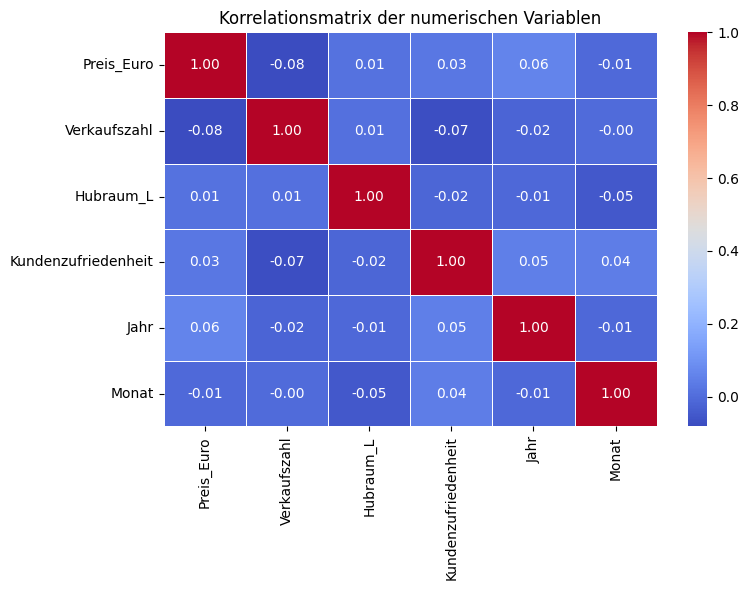

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    korrelationsmatrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Korrelationsmatrix der numerischen Variablen")

plt.tight_layout()
plt.show()

In [ ]:
preis_korrelation = korrelationsmatrix["Preis_Euro"].sort_values(
    ascending=False
)

preis_korrelation

Preis_Euro             1.000000
Jahr                   0.057965
Kundenzufriedenheit    0.025650
Hubraum_L              0.013972
Monat                 -0.008052
Verkaufszahl          -0.081754
Name: Preis_Euro, dtype: float64

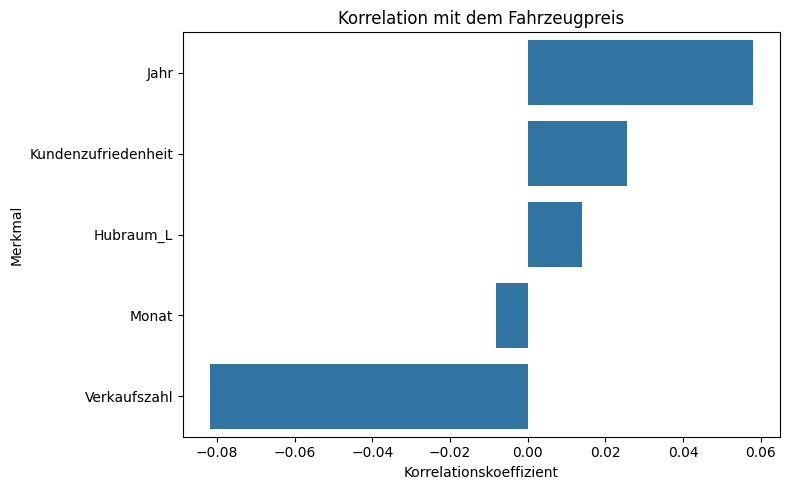

In [ ]:
preis_korrelation = preis_korrelation.drop("Preis_Euro")

plt.figure(figsize=(8,5))

sns.barplot(
    x=preis_korrelation.values,
    y=preis_korrelation.index
)

plt.title("Korrelation mit dem Fahrzeugpreis")
plt.xlabel("Korrelationskoeffizient")
plt.ylabel("Merkmal")

plt.tight_layout()
plt.show()

# Interpretation der Ergebnisse

Die Korrelationsanalyse zeigt, dass keine der verfügbaren numerischen Variablen eine starke lineare Beziehung zum Fahrzeugpreis aufweist.

Die höchste positive Korrelation wurde für die Variable "Jahr" festgestellt. Der Zusammenhang ist jedoch sehr schwach.

Auch die Variablen "Kundenzufriedenheit" und "Hubraum_L" zeigen nur geringe positive Zusammenhänge mit dem Fahrzeugpreis.

Die Variable "Verkaufszahl" weist eine schwache negative Korrelation auf. Dies deutet darauf hin, dass häufiger verkaufte Fahrzeuge tendenziell etwas günstiger sein könnten.

Insgesamt zeigen die Ergebnisse, dass die numerischen Variablen allein den Fahrzeugpreis nur begrenzt erklären können.

Es ist wahrscheinlich, dass kategorische Merkmale wie Marke, Modell, Kraftstoffart oder Getriebetyp einen größeren Einfluss auf den Fahrzeugpreis besitzen.

Die Ergebnisse der Korrelationsanalyse liefern wichtige Hinweise für die Auswahl geeigneter Merkmale in den nachfolgenden Machine-Learning-Modellen.

# Fazit

Die Korrelationsanalyse wurde durchgeführt, um Zusammenhänge zwischen den numerischen Fahrzeugmerkmalen und dem Fahrzeugpreis zu untersuchen.

Die Ergebnisse zeigen, dass keine starke lineare Korrelation zwischen den untersuchten numerischen Variablen und dem Fahrzeugpreis besteht.

Daraus lässt sich schließen, dass weitere Merkmale, insbesondere kategorische Variablen wie Marke oder Modell, für die Preisvorhersage von größerer Bedeutung sein könnten.

Die Analyse unterstützt die spätere Modellierung im Machine-Learning-Prozess und hilft bei der Identifikation relevanter Einflussfaktoren.